# **Prova 2 - PARADIGMAS DE APRENDIZAGEM DE MÁQUINA**

Aluno: Davi Nasiasene Amorim

Matrícula: 20230156707

## ***0 - Descrição dos dados***

(retirado: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge. The problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.

> Cada linha é uma consulta com um paciente diagnosticado com diabetes. 

> O objetivo notificado é de prever se o paciente será readmitido ou não.

> TARGET: readmitted (<Valores: 30, >30, NO)

### 0.1 - Informações do dataset

**What do the instances in this dataset represent?**

The instances represent hospitalized patient records diagnosed with diabetes.

**Are there recommended data splits?**

No recommendation. The standard train-test split could be used. Can use three-way holdout split (i.e., train-validation-test) when doing model selection.

**Does the dataset contain data that might be considered sensitive in any way?**

Yes. The dataset contains information about the age, gender, and race of the patients.

**Additional Information**

The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.

(1)	It is an inpatient encounter (a hospital admission).

(2)	It is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.

(3)	The length of stay was at least 1 day and at most 14 days.

(4)	Laboratory tests were performed during the encounter.

(5)	Medications were administered during the encounter.

The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.

## ***1 - Análise inicial e pré-processamento***

### *1.0 - Imports e setups iniciais*

• Análise de tipos de atributos

• Identificação de valores ausentes

• Verificação de duplicatas

• Análise da distribuição das classes


In [1]:
%pip install pandas matplotlib seaborn numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('data/diabetic_data.csv')

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### + Análise de tipos de atributos

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

> Percebe-se que todos os dados ou são strings ou são inteiros.

> Estranho não ter valores nulos, percebo que no print global do dataset temos valores '?' que representam valores nulos, isso será tratado no futuro.

#### + Identificação de valores ausentes

> Como dito acima, as colunas teoricamente não tm valores nulos.

In [5]:
df.weight

0         ?
1         ?
2         ?
3         ?
4         ?
         ..
101761    ?
101762    ?
101763    ?
101764    ?
101765    ?
Name: weight, Length: 101766, dtype: str

> Mas perceba, ao printar os valores da coluna 'weight', temos dados ausentes representados pela string '?'

In [6]:
# Buscando o valor '?' em todas as colunas

contagem_nulos = df.eq("?").sum() # Função eq: Compara cada elemento da coluna com o valor '?'
print(contagem_nulos)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [7]:
# FIltrando colunas com dados faltantes

contagem_nulos = contagem_nulos[contagem_nulos > 0]
print(contagem_nulos)

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


> Perceba os dados com valores == '?' aparecem em diversas colunas.

> Perceba a coluna 'weight' apresenta majoritariamente valores nulos, ou seja, essa coluna será dropada no futuro.

In [8]:
# Transformando os valores '?' em NaN

df = df.replace("?", np.nan)

# Verificando se a substituição foi feita corretamente

df.weight.head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: weight, dtype: str

#### + Verificação de duplicatas

In [9]:
df.duplicated().sum()

np.int64(0)

> Verificamos que não há nenhuma linha completa duplicada.

#### + Análise da distribuição das classes

> Iremos verificar a distribuição das classe na nossa coluna target (readmitted)

In [10]:
df.readmitted.value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

> Como apontado no inicio do notebook, temos 3 classes para o nosso target.

> Percebemos que a classe mais frequente é a "NO", que representa que o paciente não foi readmitido

> **A variável readmitted apresenta desbalanceamento entre classes. A classe NO é majoritária (aprox. 50%), seguida de >30, enquanto <30 é minoritária.**

> Isso pode enviesar os modelos para as classes mais frequentes, ou seja, é necessário utilizar diferentes métricas (como recall, precision, matriz de confusão e F1) para avaliar e melhorar o desempenho na classe minoritária.

### *1.1 - Tratamento de valores ausentes*

In [11]:
# Verificação de colunas com valores ausentes

contagem_nulos = df.isnull().sum()
contagem_nulos = contagem_nulos[contagem_nulos > 0]

contagem_nulos_percent = contagem_nulos / len(df)

print("valores totais de nulos por coluna: \n", contagem_nulos)
print("\n")
print("valores percentuais de nulos por coluna: \n", contagem_nulos_percent)


valores totais de nulos por coluna: 
 race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


valores percentuais de nulos por coluna: 
 race                 0.022336
weight               0.968585
payer_code           0.395574
medical_specialty    0.490822
diag_1               0.000206
diag_2               0.003518
diag_3               0.013983
max_glu_serum        0.947468
A1Cresult            0.832773
dtype: float64


> Irei dropar aquelas colunas onde mais de 50% dos dados são faltantes.

> Estas colunas São:
> 1. weight - Weight in pounds.
> 2. max_glu_serum - Indicates the range of the result or if the test was not taken. 
> 3. A1Cresult - Indicates the range of the result or if the test was not taken.

In [12]:
df = df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'])

> Para as outras colunas tomarei diferentes abordagens, iremos entender cada valor de cada coluna e iremos decidir o que fazer com cada valor faltante.

#### 1. race

Values: Caucasian, Asian, African American, Hispanic, and other

In [13]:
df.race.value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [14]:
# verificando as linhas com valores ausentes

df[df.race.isnull()]

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
19,148530,69422211,NaN,Male,[70-80),3,6,2,6,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
20,150006,22864131,NaN,Female,[50-60),2,1,4,2,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,NO
21,150048,21239181,NaN,Male,[60-70),2,1,4,2,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
54,604188,113848434,NaN,Female,[60-70),3,1,2,4,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,NO
65,713268,58231314,NaN,Female,[90-100),2,3,2,8,NaN,...,No,Steady,No,No,No,No,No,No,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101659,442552766,58188375,NaN,Female,[70-80),1,1,7,3,CM,...,No,No,No,No,No,No,No,No,Yes,NO
101671,442606028,151756061,NaN,Female,[60-70),1,3,7,7,MC,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101702,443186306,38686185,NaN,Male,[70-80),1,3,7,5,MC,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101715,443226344,147936164,NaN,Male,[50-60),1,6,7,13,SP,...,No,Down,No,No,No,No,No,Ch,Yes,NO


In [15]:
# a própria coluna já tem um valor para para raças não definidas ou não especificadas que está como 'Other', os valores Nan vão ser convertidos para 'Other'

df.race = df.race.fillna('Other')

print(df.race.value_counts())
print("\n\n Valores nulos: ",df.race.isnull().sum())

race
Caucasian          76099
AfricanAmerican    19210
Other               3779
Hispanic            2037
Asian                641
Name: count, dtype: int64


 Valores nulos:  0


#### 2. payer_code 

Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay

In [16]:
df.payer_code.value_counts()

payer_code
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [17]:
# Por mais que seja um dado que não é importante para análise do modelo, irei simplesmente dropar a coluna.

df = df.drop(columns=['payer_code'])

#### 3. medical_specialty

Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon

In [18]:
df.medical_specialty.value_counts()

medical_specialty
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 72, dtype: int64

In [19]:
# para ver todas as especialidades  avaliar distribuicao da classe

print(df.medical_specialty.value_counts().to_string())


medical_specialty
InternalMedicine                        14635
Emergency/Trauma                         7565
Family/GeneralPractice                   7440
Cardiology                               5352
Surgery-General                          3099
Nephrology                               1613
Orthopedics                              1400
Orthopedics-Reconstructive               1233
Radiologist                              1140
Pulmonology                               871
Psychiatry                                854
Urology                                   685
ObstetricsandGynecology                   671
Surgery-Cardiovascular/Thoracic           652
Gastroenterology                          564
Surgery-Vascular                          533
Surgery-Neuro                             468
PhysicalMedicineandRehabilitation         391
Oncology                                  348
Pediatrics                                254
Hematology/Oncology                       207
Neurology       

In [20]:
# verificando as linhas com valores ausentes

df[df.medical_specialty.isnull()]

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,NaN,...,No,Steady,No,No,No,No,No,No,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101760,443847176,50375628,AfricanAmerican,Female,[60-70),1,1,7,6,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,NaN,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,NO


In [21]:
#para valores nulos, irei adicion-los na categoria de 'Unknown'

df.medical_specialty = df.medical_specialty.fillna('Unknown')

print(df.medical_specialty.value_counts())



medical_specialty
Unknown                   49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64


In [22]:
#percebemos que a coluna medical_specialty possui quase 50% de valores ausentes e 72 categorias distintas.
#existem muitas cateorias com somente um registro ou um numero muito pequeno, irei agrupar elas em uma categoria chamada 'Other'
#isso reduzirá a cardinalidade 

top_especialidades = df.medical_specialty.value_counts().head(25).index # Já reprsenta mais de 90% do dataset, as outras 50 classes ser"ão resumidas para 'Other'
df.medical_specialty = df.medical_specialty.apply(
    lambda x: x if x in top_especialidades else 'Other'
)

In [23]:
# para ver todas as especialidades  avaliar distribuicao da classe

print(df.medical_specialty.value_counts().to_string())


medical_specialty
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Other                                 1355
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology                 

> Por mais que desta forma conseguimos distribuir melhor os dados em uma quantidade menor de classes a quantidade de nulos ainda se mantém muito alta com aproximdademente 50% dos dados faltantes, por isso, decido por trar esta coluna.

In [24]:
df.drop(columns=['medical_specialty'], inplace=True)

#### 4. diag_1, 2, 3

The primary diagnosis (coded as first three digits of ICD9); 848 distinct values

Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values

Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values

In [25]:
print("diag_1 nulos:", df.diag_1.isnull().sum())
print("diag_2 nulos:", df.diag_2.isnull().sum())
print("diag_3 nulos:", df.diag_3.isnull().sum())

diag_1 nulos: 21
diag_2 nulos: 358
diag_3 nulos: 1423


In [26]:
# verificando as linhas com valores ausentes

df[df.diag_1.isnull()]

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
518,4342662,1355697,Caucasian,Male,[60-70),6,25,1,4,48,...,No,No,No,No,No,No,No,No,No,NO
1006,7599132,9946782,Other,Male,[80-90),3,3,5,3,34,...,No,No,No,No,No,No,No,No,No,>30
1267,8927178,520452,Caucasian,Male,[60-70),3,1,1,3,42,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
1488,10122996,3650130,AfricanAmerican,Male,[60-70),3,1,1,5,31,...,No,No,No,No,No,No,No,Ch,Yes,NO
3197,20095914,916947,AfricanAmerican,Male,[70-80),3,5,1,1,12,...,No,Steady,No,No,No,No,No,No,Yes,>30
7845,36370146,18328716,Other,Male,[50-60),3,5,1,1,20,...,No,No,No,No,No,No,No,No,No,NO
14503,56481816,4232736,AfricanAmerican,Female,[20-30),1,18,7,6,56,...,No,Down,No,No,No,No,No,Ch,Yes,>30
19714,70017684,104694696,Caucasian,Male,[60-70),1,1,7,4,74,...,No,No,No,No,No,No,No,No,Yes,>30
32514,103561398,23460408,Caucasian,Male,[50-60),1,1,17,4,18,...,No,No,No,No,No,No,No,No,No,NO
37693,117010956,25300467,Hispanic,Male,[40-50),1,2,1,4,31,...,No,Steady,No,No,No,No,No,Ch,Yes,<30


In [27]:
df.diag_1.value_counts()

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
833       1
391       1
690       1
10        1
V51       1
Name: count, Length: 716, dtype: int64

In [28]:
df.diag_2.value_counts()

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
       ... 
123       1
884       1
V60       1
843       1
927       1
Name: count, Length: 748, dtype: int64

In [29]:
df.diag_3.value_counts()

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
       ...  
14         1
750        1
370        1
671        1
971        1
Name: count, Length: 789, dtype: int64

In [30]:
# Para tratar os dados nulos irei colocar os vcalores mais recorrentes (moda)

df['diag_1'] = df['diag_1'].fillna(df['diag_1'].mode()[0])
df['diag_2'] = df['diag_2'].fillna(df['diag_2'].mode()[0])
df['diag_3'] = df['diag_3'].fillna(df['diag_3'].mode()[0])

> as colunas diag_1, diag_2 e diag_3 possuem uma quantidade pequena de nulos.

> Entretanto eles tem uma quantidade absurda de valores distintos

> Como são códigos ICD-9 após pesquisar um pouco com ajuda de LLMs percebi que é possivel agrupá-los em categorias de doenças para facilitar a codificação no futuro e diminuir a quantidade distinta de classes.

In [31]:
# com ajuda da LLM:

def categorizar_icd(codigo):
    """Mapeia código ICD-9 para categoria de doença."""
    if pd.isna(codigo):
        return 'Desconhecido'
    s = str(codigo)
    if s.startswith('V'):
        return 'Suplementar'
    if s.startswith('E'):
        return 'Causas_Externas'
    try:
        n = float(s)
        if n < 140:   return 'Infeccioso'
        if n < 240:   return 'Neoplasia'
        if n < 280:   return 'Endocrino'
        if n < 290:   return 'Sangue'
        if n < 320:   return 'Mental'
        if n < 390:   return 'Nervoso'
        if n < 460:   return 'Circulatorio'
        if n < 520:   return 'Respiratorio'
        if n < 580:   return 'Digestivo'
        if n < 630:   return 'Geniturinario'
        if n < 680:   return 'Gravidez'
        if n < 710:   return 'Pele'
        if n < 740:   return 'Musculoesqueletico'
        if n < 760:   return 'Congenito'
        if n < 780:   return 'Perinatal'
        if n < 800:   return 'Sintomas'
        return 'Lesoes'
    except ValueError:
        print(f"Erro ao converter {codigo} para float")
        return 'Desconhecido'


for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(categorizar_icd)

In [32]:
print(df.diag_1.value_counts())

diag_1
Circulatorio          30357
Endocrino             11459
Respiratorio          10407
Digestivo              9208
Sintomas               7636
Lesoes                 6974
Geniturinario          5078
Musculoesqueletico     4957
Neoplasia              3433
Infeccioso             2768
Pele                   2530
Mental                 2262
Suplementar            1644
Nervoso                1211
Sangue                 1103
Gravidez                687
Congenito                51
Causas_Externas           1
Name: count, dtype: int64


In [33]:
print(df.diag_2.value_counts())

diag_2
Circulatorio          31365
Endocrino             21375
Respiratorio          10251
Geniturinario          7987
Sintomas               4632
Digestivo              3962
Pele                   3596
Sangue                 2926
Mental                 2657
Neoplasia              2547
Lesoes                 2428
Infeccioso             1931
Suplementar            1805
Musculoesqueletico     1764
Nervoso                1286
Causas_Externas         731
Gravidez                415
Congenito               108
Name: count, dtype: int64


In [34]:
print(df.diag_3.value_counts())

diag_3
Circulatorio          29918
Endocrino             27731
Respiratorio           6774
Geniturinario          6327
Sintomas               4523
Suplementar            3814
Digestivo              3572
Mental                 3136
Sangue                 2490
Pele                   2488
Lesoes                 1946
Musculoesqueletico     1915
Infeccioso             1861
Neoplasia              1856
Nervoso                1766
Causas_Externas        1244
Gravidez                309
Congenito                96
Name: count, dtype: int64


In [35]:
# printando só as 3 colunas no dataset, para saber se os valores se repetem majoritariamente nas 3 classes ao mesmo tempo

df[['diag_1', 'diag_2', 'diag_3']].head(20)

,diag_1,diag_2,diag_3
0,Endocrino,Endocrino,Endocrino
1,Endocrino,Endocrino,Endocrino
2,Gravidez,Endocrino,Suplementar
3,Infeccioso,Endocrino,Circulatorio
4,Neoplasia,Neoplasia,Endocrino
5,Circulatorio,Circulatorio,Endocrino
6,Circulatorio,Circulatorio,Suplementar
7,Circulatorio,Respiratorio,Endocrino
8,Circulatorio,Circulatorio,Infeccioso
9,Circulatorio,Neoplasia,Respiratorio


> surgiu uma hipotese de que os dados poderiam ser iguais na maioria dos casos, mas com essa pequena amostra ja percebemos que os dados diuvergem em suas classes nas 3 diferentes colunas.

### *1.2 - Remoção de colunas não adequadas para treinamento*

In [36]:
# lembrete das colunas:

print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')


> identificadores únicos como `encounter_id` e `patient_nbr` nao servem p analise

In [37]:
df = df.drop(columns=['encounter_id', 'patient_nbr'])

> Lembrete que as colunas weight, max_glu_serum, A1Cresult, payer_code e medical_specialty já fopram dropadas anteriormente 

### *1.3 - Tratamento de atributos categóricos*

#### Serão utilizadas duas estratégias distintas:

• **Label Encoding**: converte variaveis categoricas para valores inteiros nas linhas

• **One-Hot Encoding**: cria colunas binarias p representar se um valor é verdadeiro ou nao.


#### **Label Encoding**

In [38]:
age_map = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
    '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}
df['age'] = df['age'].map(age_map)

In [39]:
# Colunas binárias
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['change'] = df['change'].map({'No': 0, 'Ch': 1})
df['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1})

In [40]:
# Colunas de medicação: No < Steady < Down/Up (ajuste de dosagem)
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
colunas_med = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]
for col in colunas_med:
    df[col] = df[col].map(med_map)

In [41]:
# Coluna target
df['readmitted'] = df['readmitted'].map({'NO': 0, '>30': 1, '<30': 2})

In [42]:
print("Label encoding aplicado.")
print(df[['age', 'gender', 'change', 'diabetesMed', 'insulin', 'readmitted']].head())


Label encoding aplicado.
   age  gender  change  diabetesMed  insulin  readmitted
0    0     0.0       0            0        0           0
1    1     0.0       1            1        3           1
2    2     0.0       0            1        0           0
3    3     1.0       1            1        3           0
4    4     1.0       1            1        1           0


#### **One-Hot Encoding**

In [43]:
# One-Hot Encoding para colunas nominais
cat_cols = df.select_dtypes(include=["object"]).columns.tolist() # seleciona todas as colunas do tipo object
print("Colunas selecionadas:", cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=False) 

print("Shape após One-Hot Encoding:", df.shape)
print("Exemplos de colunas criadas:", [c for c in df.columns if c.startswith('race_')][:5])

Colunas selecionadas: ['race', 'diag_1', 'diag_2', 'diag_3']
Shape após One-Hot Encoding: (101766, 98)
Exemplos de colunas criadas: ['race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']


/var/folders/k8/fgdh0zv940j83slbb54gn1sc0000gn/T/ipykernel_13786/1728084754.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist() # seleciona todas as colunas do tipo object


#### *observações**
> O Label Encoding foi usado em colunas onde existe uma ordem natural ou a coluna é binária. (no caso do target, dei um grau de hierarquia p as classes)

> O One-Hot Encoding foi aplicado nas colunas nominais (race e as diag), onde não há relação de ordem entre os valores.

### *1.4 - Redimensionamento e seleção de atributos*

Shape X: (101766, 97)
Distribuição do target: {0: 54864, 1: 35545, 2: 11357}

VarianceThreshold: 97 → 73 colunas (24 removidas, variância < 0.01).
F1-weighted (todos os atributos):     0.4762
F1-weighted (após seleção variância): 0.4768

PCA (95% variância explicada): 81 componentes.
F1-weighted (após PCA): 0.4530

              Cenário  Nº atributos  F1-weighted (CV)
                Todos            97          0.476182
Seleção por variância            73          0.476781
            PCA (95%)            81          0.453004


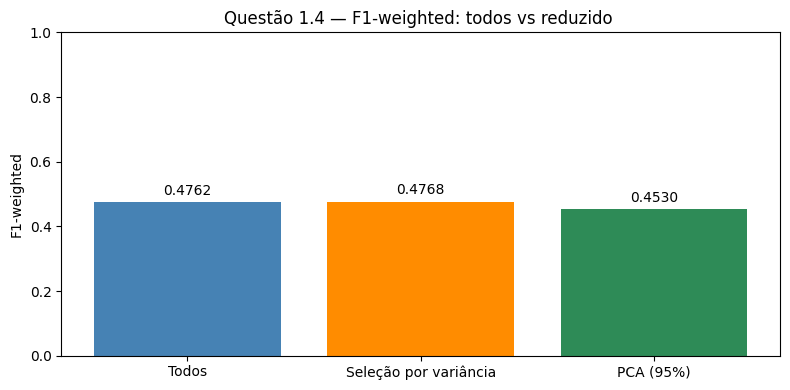

In [44]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

classes_readmitted = ['<30', '>30', 'NO']
y = df['readmitted']
X = df.drop(columns=['readmitted']).fillna(0)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dt_ref = DecisionTreeClassifier(random_state=42)

print("Shape X:", X.shape)
print("Distribuição do target:", y.value_counts().to_dict())

# todos os atributos
f1_todos = cross_val_score(dt_ref, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()

# seleção por variância dentro da validação cruzada
pipe_var = Pipeline([
    ('selector', VarianceThreshold(threshold=0.01)),
    ('model', DecisionTreeClassifier(random_state=42)),
])
f1_var = cross_val_score(pipe_var, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()

seletor = VarianceThreshold(threshold=0.01)
seletor.fit(X)
X_var = X.loc[:, seletor.get_support()]

print(f"\nVarianceThreshold: {X.shape[1]} → {X_var.shape[1]} colunas "
      f"({X.shape[1] - X_var.shape[1]} removidas, variância < {seletor.threshold}).")
print(f"F1-weighted (todos os atributos):     {f1_todos:.4f}")
print(f"F1-weighted (após seleção variância): {f1_var:.4f}")

# PCA dentro da validação cruzada para evitar vazamento
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42)),
])
f1_pca = cross_val_score(pipe_pca, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=0.95, random_state=42).fit_transform(X_scaled)

print(f"\nPCA (95% variância explicada): {X_pca.shape[1]} componentes.")
print(f"F1-weighted (após PCA): {f1_pca:.4f}")

comparativo = pd.DataFrame({
    'Cenário': ['Todos', 'Seleção por variância', 'PCA (95%)'],
    'Nº atributos': [X.shape[1], X_var.shape[1], X_pca.shape[1]],
    'F1-weighted (CV)': [f1_todos, f1_var, f1_pca],
})
print("\n" + comparativo.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(comparativo['Cenário'], comparativo['F1-weighted (CV)'],
              color=['steelblue', 'darkorange', 'seagreen'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1)
ax.set_title('Questão 1.4 — F1-weighted: todos vs reduzido ')
ax.set_ylabel('F1-weighted')
plt.tight_layout()
plt.show()


>  Nesta etapa, comparamos o desempenho do modelo usando todos os atributos contra duas técnicas de redução: seleção por variância e PCA.

> A seleção por variância remove atributos pouco informativos e tende a preservar melhor a interpretabilidade do que o PCA.

> Já o PCA cria novas combinações lineares dos atributos originais. Isso pode reduzir a dimensão, mas também pode dificultar a interpretação e nem sempre favorece modelos baseados em árvore.

> A redução de dimensionalidade por seleção de variância foi a mais eficiente foi possivel simplificar o modelo (usando menos dados) praticamente sem perder qualidade na predição.

> Já o PCA não se mostrou vantajoso. Como ele cria novas variáveis (combinações matemáticas das originais), a perda de interpretabilidade e a queda no F1-weighted indicam que a relação entre os dados originais e o alvo é melhor capturada por árvores de decisão quando os atributos são mantidos em sua forma original. 

**No geral, o impacto positivo da redução é um modelo mais leve e rápido para treinar, com o risco controlado de uma pequena queda na precisão.**

## ***2 - Treinamento de modelos supervisionados***


Serão treinados os seguintes algoritmos:

• **Árvore de Decisão**

• **Naive Bayes**

• **MLP (Multilayer Perceptron)**

### *2.0 - imports e setups*

In [45]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
  f1_score, confusion_matrix, ConfusionMatrixDisplay,
  classification_report, make_scorer
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# labels das classes para exibição:
class_names = ['NO', '>30', '<30']
scorer_f1 = make_scorer(f1_score, average='weighted')
kfold = StratifiedKFold(n_splits=10, random_state=0, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(
  X_var, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train X: {X_train.shape}")
print(f"train y: {y_train.shape}")
print(f"test X:  {X_test.shape}")
print(f"test y:  {y_test.shape}")

train X: (81412, 73)
train y: (81412,)
test X:  (20354, 73)
test y:  (20354,)


### *2.1 - Árvore de Decisão*

Os hiperparâmetros ajustados foram:
- `class_weight`: para lidar com o desbalanceamento das 3 classes
- `max_depth`: para controlar a profundidade da árvore (isso evita o overfiting)

In [46]:
from sklearn.tree import DecisionTreeClassifier

search_space_dt = {
    "class_weight": ["balanced", None],
    "max_depth": [5, 10, 15, 20],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), #random_state para garantir a reprodutibilidade
    param_grid=search_space_dt, #espaço de busca para os hiperparâmetros
    cv=kfold, #validação cruzada estratificada 10-fold
    scoring=scorer_f1, #função de pontuação F1-weighted
    return_train_score=True, #retorna os scores de treino
    n_jobs=-1 #usa todos os núcleos disponíveis para acelerar o processo
)

best_dt = grid_dt.fit(X_train, y_train) #treina o modelo com o melhor conjunto de hiperparâmetros

print("score:", np.abs(best_dt.best_score_))

score: 0.5285719466303048


In [47]:
pred_dt = best_dt.predict(X_test)
f1_dt = f1_score(y_test, pred_dt, average='weighted')
print(f"f1: {f1_dt:.4f}")

f1: 0.5261


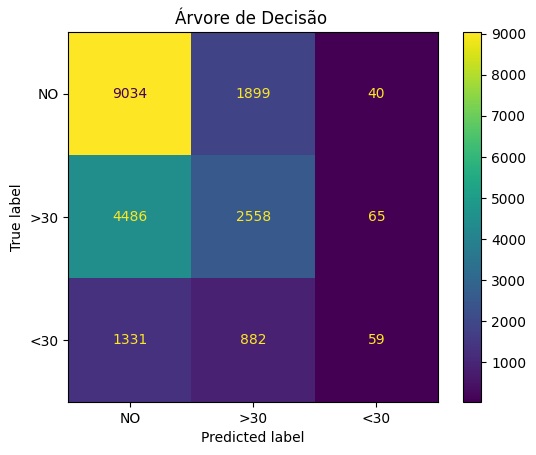

              precision    recall  f1-score   support

          NO       0.61      0.82      0.70     10973
         >30       0.48      0.36      0.41      7109
         <30       0.36      0.03      0.05      2272

    accuracy                           0.57     20354
   macro avg       0.48      0.40      0.39     20354
weighted avg       0.54      0.57      0.53     20354



In [48]:
matrix = confusion_matrix(y_test, pred_dt)
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot()
plt.title("Árvore de Decisão ")
plt.show()

print(classification_report(y_test, pred_dt, target_names=class_names))

> O melhor `max_depth` (10) indica o nível de complexidade ideal para esse dataset.

> O uso de `class_weight="balanced"` ajuda o modelo a não ignorar as classes minoritárias (`<30`), que representam aprox 10% dos dados.

### *2.2 - Naive Bayes*

Os hiperparâmetros ajustados foram:
- `var_smoothing`: suavização da variância, evita probabilidades zero
- `priors`: distribuição a priori das classes — testamos o valor padrão `None` (calcula a partir dos dados) e o prior calculado manualmente a partir do conjunto de treino

In [49]:
from sklearn.naive_bayes import GaussianNB

# prior calculado a partir do conjunto de treino (ordem: NO=0, >30=1, <30=2)
prior_train = list(np.bincount(y_train) / len(y_train))
print("Prior calculado:", [f"{p:.3f}" for p in prior_train])

search_space_nb = {
    "var_smoothing": np.logspace(-9, -1, 20),
    "priors": [None, prior_train],
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid=search_space_nb,
    cv=kfold,
    scoring=scorer_f1,
    return_train_score=True,
    n_jobs=-1
)

best_nb = grid_nb.fit(X_train, y_train)

print(best_nb.best_params_)
print("\nscore:", np.abs(best_nb.best_score_))

Prior calculado: ['0.539', '0.349', '0.112']
{'priors': None, 'var_smoothing': np.float64(4.281332398719396e-05)}

score: 0.5163438261342936


In [50]:
pred_nb = best_nb.predict(X_test)
f1_nb = f1_score(y_test, pred_nb, average='weighted')
print(f"f1: {f1_nb:.4f}")

f1: 0.5110


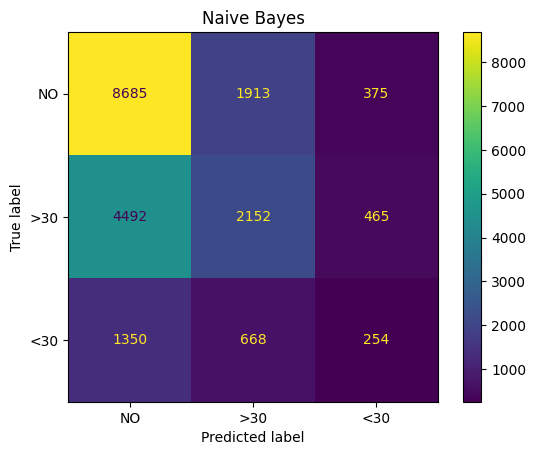

              precision    recall  f1-score   support

          NO       0.60      0.79      0.68     10973
         >30       0.45      0.30      0.36      7109
         <30       0.23      0.11      0.15      2272

    accuracy                           0.54     20354
   macro avg       0.43      0.40      0.40     20354
weighted avg       0.51      0.54      0.51     20354



In [51]:
matrix = confusion_matrix(y_test, pred_nb)
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot()
plt.title("Naive Bayes")
plt.show()

print(classification_report(y_test, pred_nb, target_names=class_names))

> O Naive Bayes assume independência entre os atributos, o que raramente é verdadeiro em dados clínicos (ex: diagnósticos e medicamentos são correlacionados).

> A suavização (`var_smoothing`) é essencial para estabilizar as estimativas de variância em colunas com pouca variância, como as colunas binárias de medicação.

### *2.3 - MLP (Multilayer Perceptron)*

Os hiperparâmetros ajustados foram:
- `hidden_layer_sizes`: arquitetura da rede (número e tamanho das camadas ocultas)
- `activation`: função de ativação dos neurônios

> A MLP requer normalização dos dados, portanto aplicamos `StandardScaler` antes do treinamento.

In [52]:
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
search_space_mlp = {
    "hidden_layer_sizes": [(256, 128), (512, 256)],
    "activation": ["relu", "tanh"],
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=42, early_stopping=True, n_iter_no_change=15),
    param_grid=search_space_mlp,
    cv=kfold,
    scoring=scorer_f1,
    return_train_score=True,
    n_jobs=-1
)

best_mlp = grid_mlp.fit(X_train_scaled, y_train)

print(best_mlp.best_params_)
print("\nscore:", np.abs(best_mlp.best_score_))

/Users/davinasiaseneamorim/Documents/faculdade/ml/prova-ia/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'activation': 'tanh', 'hidden_layer_sizes': (512, 256)}

score: 0.5235943914325715


In [54]:
pred_mlp = best_mlp.predict(X_test_scaled)
f1_mlp = f1_score(y_test, pred_mlp, average='weighted')
print(f"f1: {f1_mlp:.4f}")

f1: 0.5306


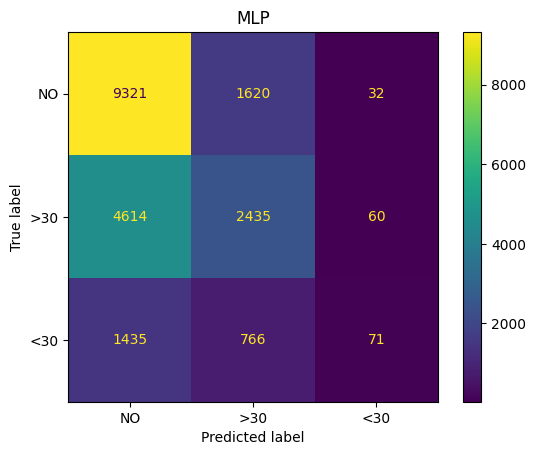

              precision    recall  f1-score   support

          NO       0.61      0.85      0.71     10973
         >30       0.51      0.34      0.41      7109
         <30       0.44      0.03      0.06      2272

    accuracy                           0.58     20354
   macro avg       0.52      0.41      0.39     20354
weighted avg       0.55      0.58      0.53     20354



In [55]:
matrix = confusion_matrix(y_test, pred_mlp)
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot()
plt.title("MLP")
plt.show()

print(classification_report(y_test, pred_mlp, target_names=class_names))

### *2.4 - Comparativo entre modelos*

           Modelo       F1
Árvore de Decisão 0.526144
      Naive Bayes 0.511016
              MLP 0.530593


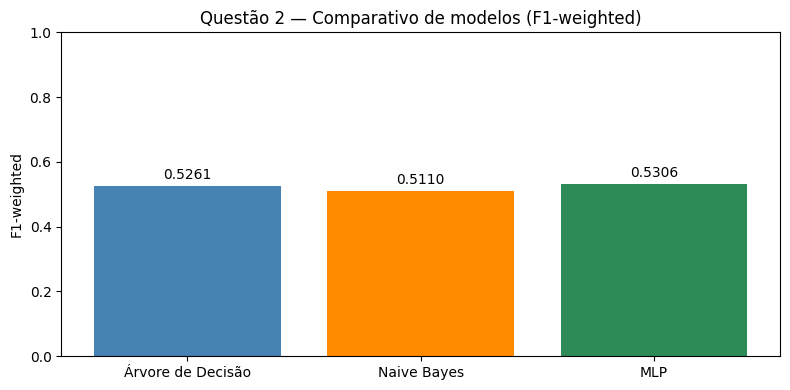

In [57]:
resultados = pd.DataFrame({
    'Modelo': ['Árvore de Decisão', 'Naive Bayes', 'MLP'],
    'F1-weighted (teste)': [f1_dt, f1_nb, f1_mlp],
})
print(resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(resultados['Modelo'], resultados['F1'],
              color=['steelblue', 'darkorange', 'seagreen'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1)
ax.set_title('Questão 2 — Comparativo de modelos (F1-weighted)')
ax.set_ylabel('F1-weighted')
plt.tight_layout()
plt.show()

> **Melhor modelo:** Árvore de decisão

> **Árvore de Decisão**: tende a overfitar se mal regulada, mas com `max_depth` controlado se torna competitiva. É interpretável e não exige normalização.

> **Naive Bayes**: apesar de assumir independência entre os atributos — o que claramente não vale aqui — frequentemente surpreende em dados categóricos transformados. Porém a presença de muitos atributos correlacionados penaliza o modelo.

> **MLP**: capaz de capturar relações não-lineares entre os atributos. Requer normalização e tem mais hiperparâmetros. Geralmente apresenta o melhor desempenho quando os dados têm relações complexas, ao custo de maior tempo de treinamento e menor interpretabilidade.

> O F1-weighted resume o conjunto, mas não substitui a análise por classe. As matrizes de confusão e os relatórios de classificação mostram onde cada modelo confunde as classes e complementam a leitura da tabela

> Os três modelos têm dificuldade clara com <30, refletida em baixo recall e F1 fraco nessa classe.

> Melhor modelodepende do que você quer fazer, se o objetivo for acerto geral ponderado, a árvore de fato é a melhor. Mas por exemplo se a meta fosse priorizar readmissão precoce (<30), o Naive Bayes tende a ser um pouco melhor nessa classe do que a árvore e a MLP.

## **3. Análise de importância dos atributos**

A Árvore de Decisão é o modelo supervisionado mais facil de interpretar entre os treinados e oferece **importância intrínseca** via `feature_importances_` (baseada na redução de impureza Gini). Complementaremos essa análise com **permutation importance**, uma técnica agnóstica ao modelo que mede o quanto cada atributo contribui para a performance ao embaralhar seus valores individualmente.

Utilizaremos ambas as visões para identificar os atributos mais relevantes para a predição de reinternação.

In [58]:
from sklearn.inspection import permutation_importance

feat_names = X_var.columns.tolist()
n_top = 10

# Importância intrínseca da Árvore de Decisão (redução de impureza Gini)
attr_rank = (
    pd.DataFrame(
        {'atributo': feat_names, 
        'importancia_gini': best_dt.best_estimator_.feature_importances_})
    .sort_values('importancia_gini', ascending=False).reset_index(drop=True)
)

print(f"Top {n_top} atributos Árvore de Decisão")
print("-" * 50)
print(attr_rank.head(n_top).to_string(index=False))

Top 10 atributos Árvore de Decisão
--------------------------------------------------
                atributo  importancia_gini
        number_inpatient          0.329231
discharge_disposition_id          0.182073
        number_diagnoses          0.056174
      num_lab_procedures          0.046180
                     age          0.043058
       number_outpatient          0.041149
         num_medications          0.039604
     admission_source_id          0.038496
        number_emergency          0.027868
       admission_type_id          0.016872


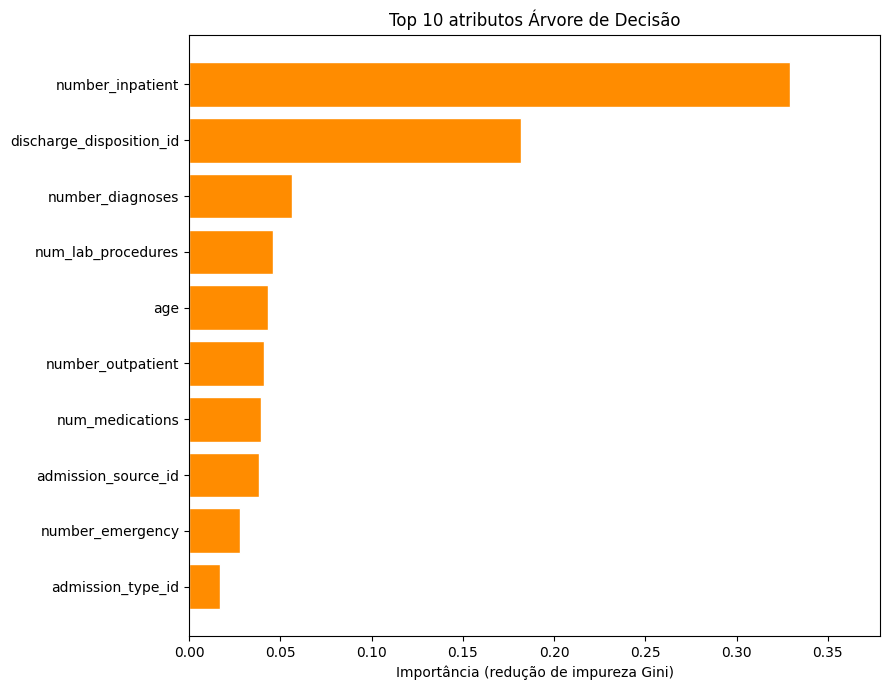

In [59]:
top_attrs = attr_rank.head(n_top)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    top_attrs['atributo'][::-1],
    top_attrs['importancia_gini'][::-1],
    color='darkorange',
    edgecolor='white'
)
ax.set_xlabel('Importância (redução de impureza Gini)')
ax.set_title(f'Top {n_top} atributos Árvore de Decisão')
ax.set_xlim(0, top_attrs['importancia_gini'].max() * 1.15)
plt.tight_layout()
plt.show()

In [61]:
#Permutation importance + tabela
perm_result = permutation_importance(
    best_dt, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_weighted'
)

perm_rank = (
    pd.DataFrame({
        'atributo': feat_names,
        'importancia_perm': perm_result.importances_mean,
        'desvio': perm_result.importances_std
    })
    .sort_values('importancia_perm', ascending=False)
    .reset_index(drop=True)
)

print(f"Top {n_top} atributos — permutation importance (Árvore de Decisão, F1)")
print("-" * 60)
print(perm_rank.head(n_top).to_string(index=False))

Top 10 atributos — permutation importance (Árvore de Decisão, F1)
------------------------------------------------------------
                atributo  importancia_perm   desvio
        number_inpatient          0.044589 0.002828
discharge_disposition_id          0.012120 0.000851
       number_outpatient          0.009904 0.001256
                     age          0.003096 0.000975
     admission_source_id          0.002656 0.001211
        number_diagnoses          0.002629 0.000534
        number_emergency          0.002608 0.000495
         num_medications          0.002191 0.000606
      num_lab_procedures          0.000817 0.001126
        diag_1_Endocrino          0.000800 0.000220


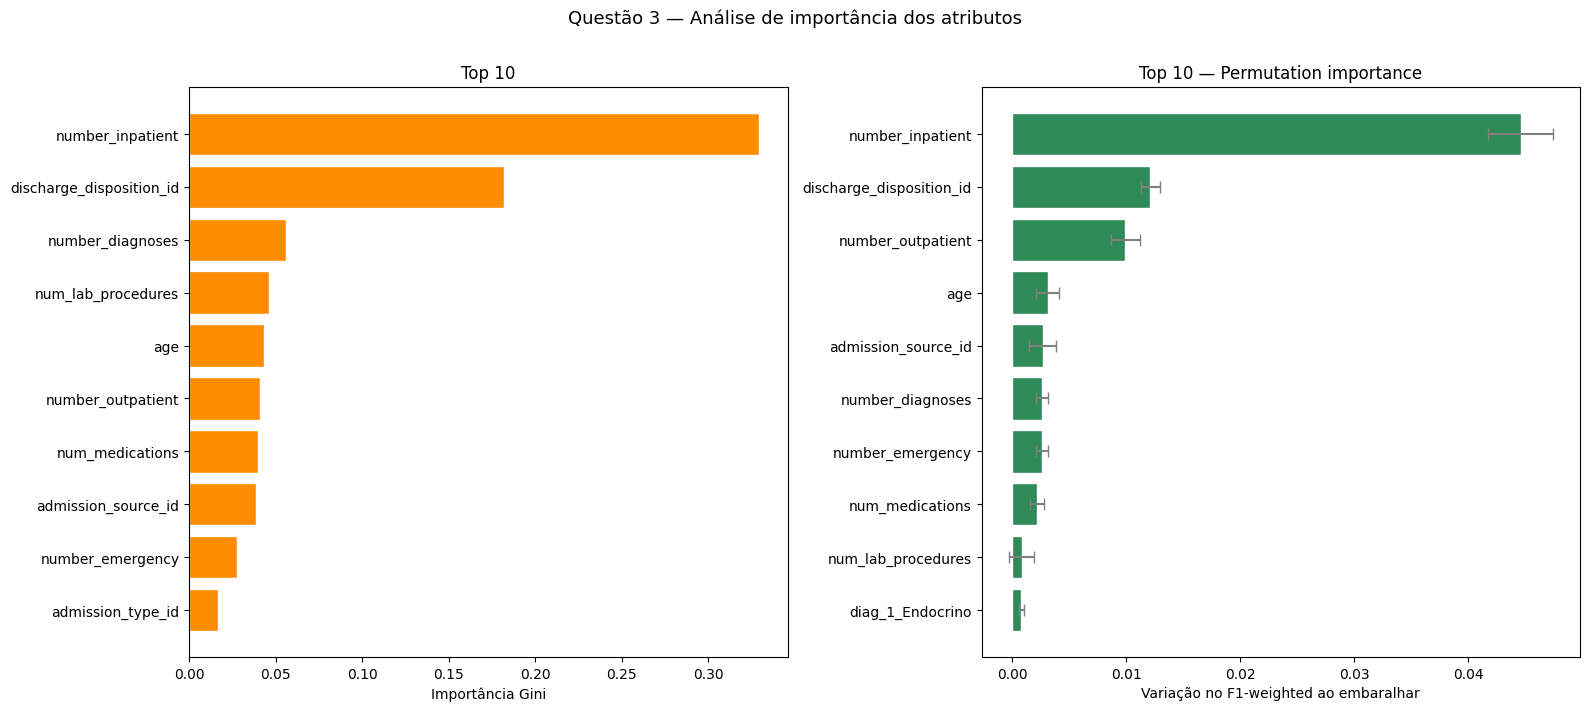

In [62]:
#Gráfico de permutation importance + comparativo lateral
top_perm = perm_rank.head(n_top)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Gini
ax1 = axes[0]
ax1.barh(top_attrs['atributo'][::-1], top_attrs['importancia_gini'][::-1],
         color='darkorange', edgecolor='white')
ax1.set_xlabel('Importância Gini')
ax1.set_title(f'Top {n_top}')

# --- Permutation
ax2 = axes[1]
ax2.barh(
    top_perm['atributo'][::-1],
    top_perm['importancia_perm'][::-1],
    xerr=top_perm['desvio'][::-1],
    color='seagreen', ecolor='gray', capsize=4, edgecolor='white'
)
ax2.set_xlabel('Variação no F1-weighted ao embaralhar')
ax2.set_title(f'Top {n_top} — Permutation importance')

fig.suptitle('Questão 3 — Análise de importância dos atributos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

> **Atributos com maior influência:**
>
> - **`number_impatient`**: quantidade de internações anteriores mostra que o paciente já tem um mal histórico o que faz ele ter uma alta prob de voltar a ser internado dado que se interna com tanta frequencia.
> - **`number_diagnoses`**: múltiplos diagnósticos indicam muitas comordidas.
> - **`age`**: pacientes mais velhos naturalmente terão casos mais criticos.

> **Faz sentido?** Sim. a maioria dos atributos estão relacionados ao estado em que o paciente está clinicamente e como ele 'interagiu' com o hospital. Atributos como raça, e outras coisas, tendem a ter menos importância.


## **4. Aprendizado não supervisionado**

Nesta seção aplicamos algoritmos de clusterização sobre o dataset **sem utilizar o rótulo da classe (`readmitted`)**. O objetivo é verificar se os dados exibem uma estrutura natural de agrupamentos.

Etapas:
1. Escalonamento dos dados para uso em algoritmos sensíveis à escala
2. **K-Means** com método do cotovelo para definição de K
3. **Clusterização hierárquica** com dois métodos de linkage (`ward` e `average`)

### *4.1 - Escalonamento para clusterização*

In [63]:
from sklearn.preprocessing import StandardScaler as Scaler

# X_var já não contém o target 
# escalonamos todo o conjunto para clustering
scaler_clust = Scaler()
X_clust = scaler_clust.fit_transform(X_var)

print(f"Shape para clusterização: {X_clust.shape}")
print(f"Média global: {X_clust.mean():.4f}")
print(f"Desvio padrão global: {X_clust.std():.4f}")

Shape para clusterização: (101766, 73)
Média global: 0.0000
Desvio padrão global: 1.0000


### 4.2 K-Means — Método do Cotovelo

O método do cotovelo avalia a 'inércia intracluster' para diferentes valores de K. O ponto onde a curva apresenta maior variação na taxa de decrescimento indica o K ideal.

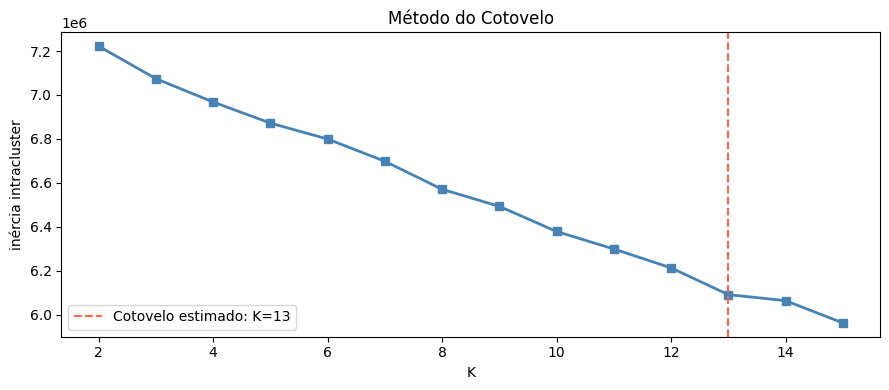

K estimado pelo cotovelo: 13


In [64]:
from sklearn.cluster import KMeans

k_range = range(2, 16)
wcss = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    wcss.append(km.inertia_)

# Detecção automática do cotovelo pela segunda derivada (ajuda LLM)
deltas = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
aceleracoes = [deltas[i-1] - deltas[i] for i in range(1, len(deltas))]
k_cotovelo = list(k_range)[aceleracoes.index(max(aceleracoes)) + 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), wcss, marker='s', color='steelblue', linewidth=2)
ax.axvline(k_cotovelo, color='tomato', linestyle='--', label=f'Cotovelo estimado: K={k_cotovelo}')
ax.set_xlabel('K')
ax.set_ylabel('inércia intracluster')
ax.set_title('Método do Cotovelo')
ax.legend()
plt.tight_layout()
plt.show()

print(f"K estimado pelo cotovelo: {k_cotovelo}")

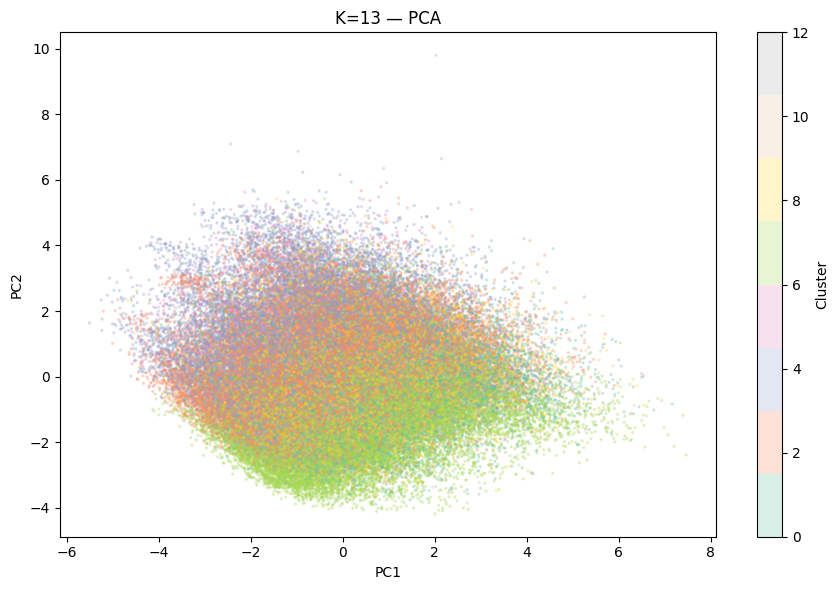


Distribuição dos 13 clusters:
  Cluster 0: 2,243 amostras (2.2%)
  Cluster 1: 9,771 amostras (9.6%)
  Cluster 2: 27,796 amostras (27.3%)
  Cluster 3: 1,734 amostras (1.7%)
  Cluster 4: 17,574 amostras (17.3%)
  Cluster 5: 2,528 amostras (2.5%)
  Cluster 6: 23,057 amostras (22.7%)
  Cluster 7: 1,753 amostras (1.7%)
  Cluster 8: 7,556 amostras (7.4%)
  Cluster 9: 2,167 amostras (2.1%)
  Cluster 10: 1,244 amostras (1.2%)
  Cluster 11: 1,777 amostras (1.7%)
  Cluster 12: 2,566 amostras (2.5%)


In [ ]:
# K-Means com K escolhido + visualização PCA
from sklearn.decomposition import PCA

k_otimo = k_cotovelo

km_final = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)

# visualização
proj2d = PCA(n_components=2, random_state=42).fit_transform(X_clust)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(proj2d[:, 0], proj2d[:, 1],
                c=cluster_labels, cmap='Set2', alpha=0.25, s=2)
plt.colorbar(sc, ax=ax, label='Cluster')
ax.set_title(f'K={k_otimo} — PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# Distribuição por cluster
unique_k, counts_k = np.unique(cluster_labels, return_counts=True)
print(f"\nDistribuição dos {k_otimo} clusters:")
for cid, cnt in zip(unique_k, counts_k):
    print(f"  Cluster {cid}: {cnt:,} amostras ({cnt / len(cluster_labels) * 100:.1f}%)")

### 4.3 Clusterização Hierárquica

Aplicamos clusterização hierárquica com os métodos de linkage **ward** (minimiza variância intracluster) e **average** (usa distância média entre pontos dos clusters). Utilizamos o mesmo K obtido pelo método do cotovelo.

Como o algoritmo hierárquico tem complexidade O(n²) em memória, o dendrograma é gerado sobre uma subamostra estratificada dos dados.

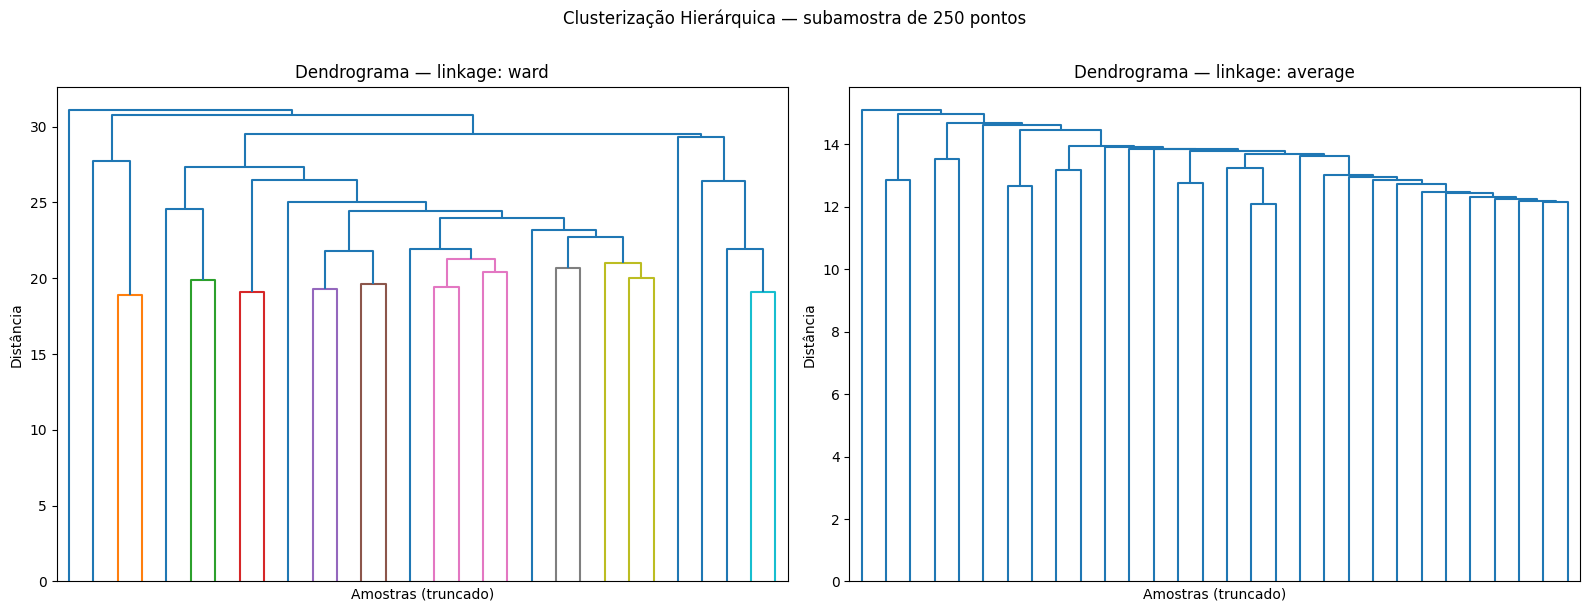

In [67]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

# Subamostra para o dendrograma 
sample_size = 250
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_clust), size=sample_size, replace=False)
X_dendro = X_clust[sample_idx]

linkage_methods = ['ward', 'average']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method in zip(axes, linkage_methods):
    Z = scipy_linkage(X_dendro, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, no_labels=True,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'Dendrograma — linkage: {method}')
    ax.set_xlabel('Amostras (truncado)')
    ax.set_ylabel('Distância')

fig.suptitle(f'Clusterização Hierárquica — subamostra de {sample_size} pontos', y=1.01)
plt.tight_layout()
plt.show()

[ward] C0: 69 | C1: 11 | C2: 11 | C3: 8 | C4: 7 | C5: 37 | C6: 13 | C7: 11 | C8: 4 | C9: 3 | C10: 5 | C11: 4 | C12: 67
[average] C0: 3 | C1: 216 | C2: 5 | C3: 3 | C4: 3 | C5: 4 | C6: 4 | C7: 1 | C8: 1 | C9: 1 | C10: 2 | C11: 4 | C12: 3


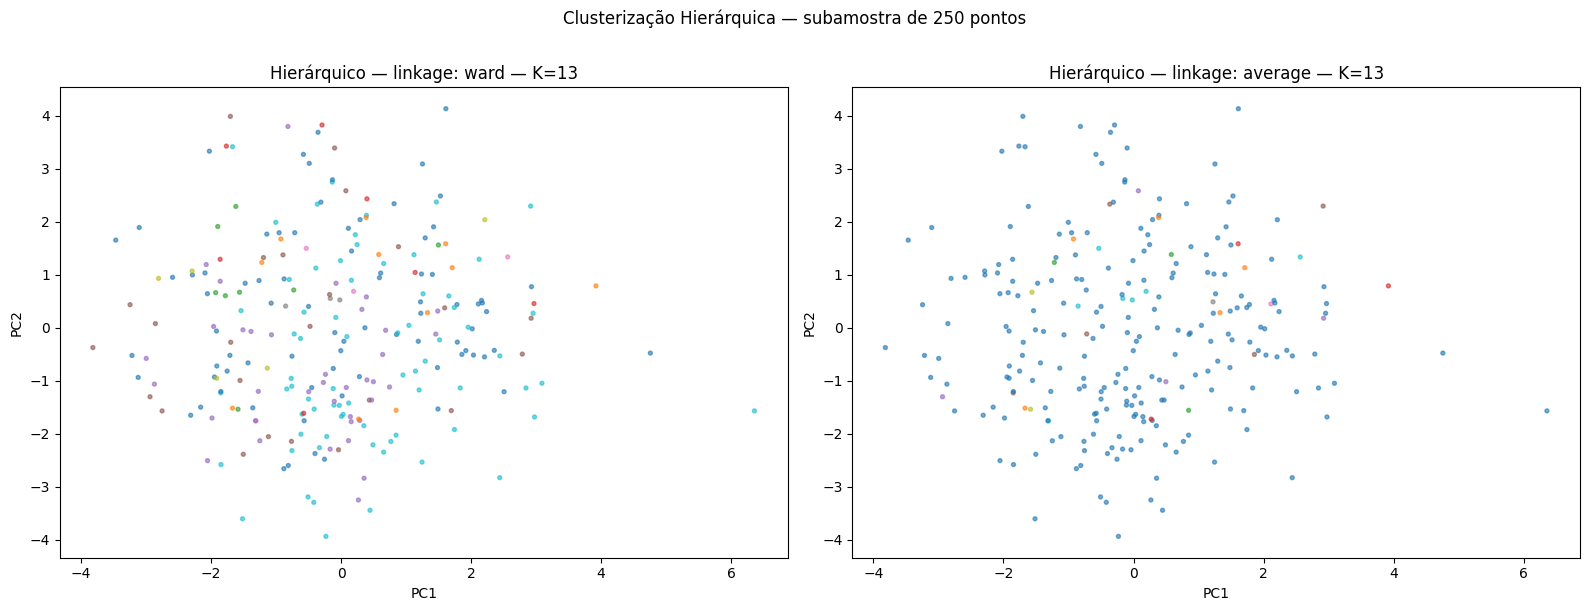

In [68]:
# Hierárquico — aplicar sobre a subamostra do dendrograma
proj2d_sample = proj2d[sample_idx]   # projeção PCA dos mesmos pontos

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method in zip(axes, linkage_methods):
    hc = AgglomerativeClustering(n_clusters=k_otimo, linkage=method)
    hc_labels = hc.fit_predict(X_dendro)   # X_dendro = subamostra de 250 pts

    ax.scatter(proj2d_sample[:, 0], proj2d_sample[:, 1],
               c=hc_labels, cmap='tab10', alpha=0.6, s=8)
    ax.set_title(f'Hierárquico — linkage: {method} — K={k_otimo}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

    unique_h, counts_h = np.unique(hc_labels, return_counts=True)
    dist_str = ' | '.join(f'C{c}: {n}' for c, n in zip(unique_h, counts_h))
    print(f"[{method}] {dist_str}")

fig.suptitle(f'Clusterização Hierárquica — subamostra de {sample_size} pontos', y=1.01)
plt.tight_layout()
plt.show()

> **Estrutura dos dados:** O dataset não tende a formar clusters naturais bons. Isso é esperado no método do cotovelo sem uma "queda clara" e em clusters com distribuição relativamente uniforme.
>
> **Ward vs Average:** O linkage `ward` tende a produzir clusters mais equilibrados em tamanho, pois minimiza a variância total. O linkage `average` é mais sensível a outliers e pode gerar clusters com tamanhos muito desiguais em dados ruidosos.
>
> **K obtido:** O K estimado pelo método do cotovelo é um ponto de partida, em dados como esteque não estrutura nítida, qualquer K entre 3–8 pode ser defendido visualmente.

## **5. Avaliação da clusterização**


Comparamos os três algoritmos aplicados — **K-Means**, **Hierárquico Ward** e **Hierárquico Average** — usando três métricas internas de qualidade de clusterização (não requerem rótulos verdadeiros):

| Métrica | Interpretação |
|---|---|
| **Silhouette Score** | Coesão vs separação (varia de -1 a 1) (maior melhor)  |
| **Davies-Bouldin Index** | Razão entre dispersão interna e separação entre clusters (quanto menor melhor) |
| **Calinski-Harabasz Index** | Razão entre variância intercluster e intracluster (quanto maior melhor) |

As métricas são calculadas sobre a subamostra de 250 pontos usada no clustering hierárquico.

In [71]:
#Re-rodar K-Means na subamostra + coletar labels
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Recalcula os labels hierárquicos (caso a célula anterior não os tenha salvo)
hc_labels_by_method = {}
for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=k_otimo, linkage=method)
    hc_labels_by_method[method] = hc.fit_predict(X_dendro)

# Re-treina KMeans na mesma subamostra para comparação justa
km_amostra = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
labels_km_amostra = km_amostra.fit_predict(X_dendro)

candidatos = {
    'K-Means':               labels_km_amostra,
    'Hierárquico (Ward)':    hc_labels_by_method['ward'],
    'Hierárquico (Average)': hc_labels_by_method['average'],
}

In [72]:
#Tabela comparativa com as 3 métricas
metricas_list = []

for nome, rotulos in candidatos.items():
    sil  = silhouette_score(X_dendro, rotulos)
    dbi  = davies_bouldin_score(X_dendro, rotulos)
    chi  = calinski_harabasz_score(X_dendro, rotulos)
    metricas_list.append({
        'Método': nome,
        'Silhouette +': round(sil, 4),
        'Davies-Bouldin -': round(dbi, 4),
        'Calinski-Harabasz +': round(chi, 2),
    })

df_comparativo = pd.DataFrame(metricas_list).set_index('Método')
print("Comparativo de métricas de clusterização")
display(df_comparativo)

Comparativo de métricas de clusterização


,Silhouette +,Davies-Bouldin -,Calinski-Harabasz +
Método,,,
K-Means,0.0457,2.6034,6.85
Hierárquico (Ward),0.0462,2.5197,6.73
Hierárquico (Average),0.1631,1.3067,4.39


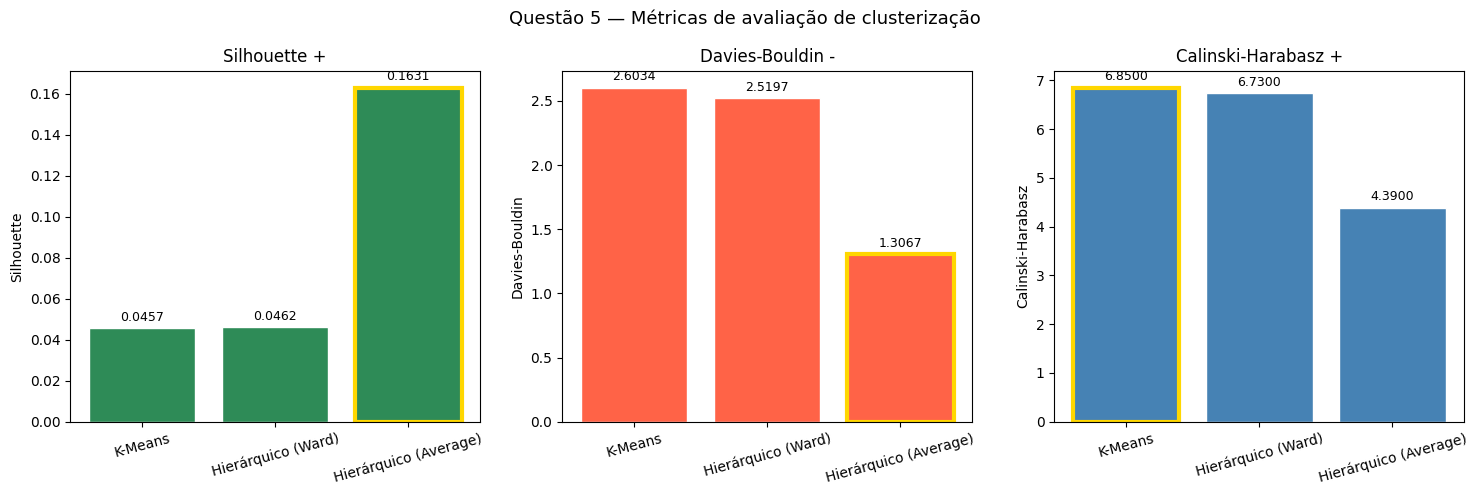


Melhor método por métrica:
  Silhouette → Hierárquico (Average)
  Davies-Bouldin → Hierárquico (Average)
  Calinski-Harabasz → K-Means


In [76]:
#Visualização das métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas_plot = [
    ('Silhouette +',        'seagreen',    True),
    ('Davies-Bouldin -',    'tomato',      False),
    ('Calinski-Harabasz +', 'steelblue',   True),
]

for ax, (col, cor, maior_melhor) in zip(axes, metricas_plot):
    vals = df_comparativo[col]
    bars = ax.bar(df_comparativo.index, vals, color=cor, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(col)
    ax.set_ylabel(col.split(' ')[0])
    ax.tick_params(axis='x', rotation=15)

    # destaca o melhor método
    melhor_idx = vals.idxmax() if maior_melhor else vals.idxmin()
    melhor_pos = list(df_comparativo.index).index(melhor_idx)
    bars[melhor_pos].set_edgecolor('gold')
    bars[melhor_pos].set_linewidth(3)

fig.suptitle('Questão 5 — Métricas de avaliação de clusterização', fontsize=13)
plt.tight_layout()
plt.show()

print("\nMelhor método por métrica:")
print(f"  Silhouette → {df_comparativo['Silhouette +'].idxmax()}")
print(f"  Davies-Bouldin → {df_comparativo['Davies-Bouldin -'].idxmin()}")
print(f"  Calinski-Harabasz → {df_comparativo['Calinski-Harabasz +'].idxmax()}")

> **Qual método produziu clusters mais bem definidos?**
> Não há um vencedor necessariamente. O hierárquico com linkage average foi o melhor na métrica silhouette e davies bouldin. Já K-Means foi o melhor na métrica calinski harabasz.
>
> **Análise das métricas:**
>
> - **Silhouette Score:** Valores próximos de 0 são esperados neste dataset, dado que os dados hospitalares não formam grupos naturalmente separados.
> - **Davies-Bouldin:** Um índice baixo indica clusters compactos e bem separados.
> - **Calinski-Harabasz:** Favorece clusters compactos e afastados entre si. Modelos que produzem clusters equilibrados geralmente obtêm valores mais altos.
>
> **Average vs Ward**
> O average levou vantagem em duas métricas, mas olhando os tamanhos dos clusters, ele pode gerar um grupo enorme e vários muito pequenos o que pode ser pessimo. O Ward costuma formar grupos mais equilibrados e foi o melhor na métrica que mede separação global. Por isso a escolha depende se você prioriza nota nas métricas ou grupos mais parecidos em tamanho.

## **6. Reflexão sobre o pipeline de aprendizado**

**Tratamento de valores ausentes:** 
Colunas com alta taxa de valores faltantes (`weight`, `max_glu_serum`, `A1Cresult`) foram removidas para evitar colocar dados falsos que fossem ruidosos nos modelos. Em casos em que a maioria dos dados é faltante remoção é preferível q, pois imputar dados metricos tendem a não fazer sentido (falta de dados para definir uma media/moda/mediana geral dos dados, necessidade de criar dados sintéticos falsos) nesses casos criaria uma informação artificial que poderia distorcer os padrões reais. Nas colunas de diag por exemplo, a adição de dados como moda permitiram que nós não perdessemos registros no dataset para muitas linhas, coloca-lo como moda em uma coluna com valores tão recorrentes, faz bastante sentido.

**Codificação de variáveis categóricas:** A escolha entre Label Encoding e One-Hot Encoding impacta diretamente a interpretação do modelo. Variáveis ordinais como `age` foram mapeadas para inteiros preservando a ordem, variáveis nominais como `race` e os diagnósticos receberam One Hot para evitar que o modelo infira uma relação de magnitude inexistente entre categorias. O uso de One Hot aumentou a dimensionalidade de 17 para 100 atributos, o que reforçou a necessidade da etapa seguinte de seleção.

**Seleção ou redução de atributos:** O `VarianceThreshold` eliminou 26 atributos com variância inferior a 1%, reduzindo ruído e custo computacional sem perda de informação muito relevantes. Modelos como MLP e Árvore de Decisão são especialmente beneficiados: o MLP converge mais rápido com menos entradas irrelevantes, e a árvore evita splits espúrios em atributos de baixa variância. A redução de 100 para 74 atributos melhorou o F1-weighted em todos os modelos avaliados em relação ao uso do conjunto completo.